# CS 598 DL4H — WatchSleepNet

End-to-end pipeline: DREAMT dataset loading → IBI preprocessing → WatchSleepNet training and evaluation.

**Branch:** `watch-sleep-net-model`  
**Repo:** [cs598-DLH-WatchSleepNet](https://github.com/jananij2/cs598-DLH-WatchSleepNet)

## Install Dependencies

In [1]:
requirements = """\
  numpy~=2.2.0
  pandas~=2.3.1
  pyarrow~=22.0.0
  polars~=1.35.2
  narwhals~=2.13.0
  scikit-learn~=1.7.0
  transformers~=4.53.2
  accelerate
  peft
  pydantic~=2.11.7
  urllib3~=2.5.0
  mne~=1.10.0
  networkx
  tqdm
  einops>=0.8.0
  more-itertools~=10.8.0
  linear-attention-transformer>=0.19.1
  dask[complete]~=2025.11.0
  litdata~=0.2.59
  rdkit
  ogb>=1.3.5
  git+https://github.com/sunlabuiuc/PyHealth.git
  """

with open("requirements.txt", "w") as f:
    f.write(requirements)

print(requirements)

  numpy~=2.2.0
  pandas~=2.3.1
  pyarrow~=22.0.0
  polars~=1.35.2
  narwhals~=2.13.0
  scikit-learn~=1.7.0
  transformers~=4.53.2
  accelerate
  peft
  pydantic~=2.11.7
  urllib3~=2.5.0
  mne~=1.10.0
  networkx
  tqdm
  einops>=0.8.0
  more-itertools~=10.8.0
  linear-attention-transformer>=0.19.1
  dask[complete]~=2025.11.0
  litdata~=0.2.59
  rdkit
  ogb>=1.3.5
  git+https://github.com/sunlabuiuc/PyHealth.git
  


In [2]:
!pip install -q -r requirements.txt

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 5.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 519.2 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 kB 4.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.6/68.6 kB 7.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.4/69.4 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.5/16.5 MB 89.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 84.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.7/47.7 MB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 426.4/426.4 kB 38.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 90.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 65.3 MB/s et

In [ ]:
# Cell 3 — HARD RESTART the runtime (required; numpy was downgraded from Colab's default).
# After this cell runs, the kernel dies. Manually run the cells below it.
import os
os.kill(os.getpid(), 9)

# INTENTIONAL RESTART

After all the deps are installed, we are forcing a runtime restart. After that takes place, run the below cells manually.

In [1]:
# Cell 4 — run AFTER the restart. Imports should now succeed.
from pyhealth.datasets import BaseDataset
from pyhealth.models import BaseModel
print("pyhealth import OK")

pyhealth import OK


In [1]:
# Install specific compatible versions of torch
# !pip uninstall -y torch torchvision torchaudio
# !pip install torch==2.2.2 torchvision==0.17.2 -q

# Install PyHealth from source (use this during active contribution work)
# !pip install git+https://github.com/sunlabuiuc/PyHealth.git -q

# Other common dependencies
# !pip install numpy pandas scikit-learn matplotlib -q

Found existing installation: torch 2.10.0+cpu
Uninstalling torch-2.10.0+cpu:
  Successfully uninstalled torch-2.10.0+cpu
Found existing installation: torchvision 0.25.0+cpu
Uninstalling torchvision-0.25.0+cpu:
  Successfully uninstalled torchvision-0.25.0+cpu
Found existing installation: torchaudio 2.10.0+cpu
Uninstalling torchaudio-2.10.0+cpu:
  Successfully uninstalled torchaudio-2.10.0+cpu
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 755.5/755.5 MB 537.5 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 66.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 56.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 48.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 34.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 MB 1.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121

In [2]:
import pyhealth
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print(f"PyHealth version: {pyhealth.__version__}")
print("All imports successful.")

PyHealth version: 2.0.0
All imports successful.


## Mount Google Drive

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import os

# Base path — adjust if your Drive folder structure differs
DRIVE_BASE = '/content/drive/MyDrive/cs598-watchsleepnet'

PATHS = {
    'raw':         os.path.join(DRIVE_BASE, 'raw'),
    'processed':   os.path.join(DRIVE_BASE, 'processed'),
    'dreamt_npz':  os.path.join(DRIVE_BASE, 'processed', 'dreamt_npz'),
    'mesa_npz':    os.path.join(DRIVE_BASE, 'processed', 'mesa_npz'),
    'shhs_npz':    os.path.join(DRIVE_BASE, 'processed', 'shhs_npz'),
    'models':      os.path.join(DRIVE_BASE, 'models'),
    'results':     os.path.join(DRIVE_BASE, 'results'),
}

for name, path in PATHS.items():
    os.makedirs(path, exist_ok=True)
    print(f"{name:12s} → {path}")

raw          → /content/drive/MyDrive/cs598-watchsleepnet/raw
processed    → /content/drive/MyDrive/cs598-watchsleepnet/processed
dreamt_npz   → /content/drive/MyDrive/cs598-watchsleepnet/processed/dreamt_npz
mesa_npz     → /content/drive/MyDrive/cs598-watchsleepnet/processed/mesa_npz
shhs_npz     → /content/drive/MyDrive/cs598-watchsleepnet/processed/shhs_npz
models       → /content/drive/MyDrive/cs598-watchsleepnet/models
results      → /content/drive/MyDrive/cs598-watchsleepnet/results


## Dataset Implementation (dreamt.py)

In [ ]:
import os
import numpy as np
import pandas as pd
from pathlib import Path
from typing import Dict, List, Any, Optional
from pyhealth.datasets import BaseDataset


class DREAMTDataset(BaseDataset):
    """Dataset for Real-time sleep stage Estimation (DREAMT).

    Reads per-subject NPZ files produced by preprocess_dreamt.py.
    Each NPZ contains IBI at 25 Hz and integer-encoded stage labels.
    """

    def __init__(self, root: str, dev: bool = True, **kwargs):
        import time
        unique_name = f"DREAMT_{int(time.time())}"
        super(DREAMTDataset, self).__init__(
            dataset_name=unique_name,
            root=root,
            tables=["npz"],
            dev=dev,
            **kwargs
        )

    def parse_basic_info(self) -> Dict[str, Dict[str, Any]]:
        """Reads subject metadata from NPZ files."""
        data = {}
        for npz_file in sorted(Path(self.root).glob('*.npz')):
            sid = npz_file.stem
            npz = np.load(npz_file)
            data[sid] = {
                'ahi': float(npz['ahi']),
                'fs':  int(npz['fs']),
            }
        print(f"DEBUG: Found {len(data)} subjects: {list(data.keys())[:5]}")
        return data

    def parse_tables(self) -> Dict[str, Dict[str, List]]:
        """Parses per-subject NPZ files from the preprocessed directory."""
        patients = self.parse_basic_info()

        final_patients = {}
        for sid, info in patients.items():
            npz = np.load(Path(self.root) / f"{sid}.npz")
            final_patients[sid] = {
                'patient_id': sid,
                'ahi':        info['ahi'],
                'ibi':        npz['data'].tolist(),    # float32 IBI at 25 Hz
                'label':      npz['stages'].tolist(),  # int32 labels (0=W,1=N1,2=N2,3=N3,4=R)
            }

        self.patients = final_patients
        return final_patients

## Task Implementation (sleep_staging_dreamt.py)

In [7]:
from typing import Dict, List

def sleep_staging_dreamt_fn(patient: Dict) -> List[Dict]:
    """Task function to window IBI data into 30-second epochs.

    Window Logic: 30 seconds @ 25 Hz = 750 samples.
    Labels are already integer-encoded (W=0, N1=1, N2=2, N3=3, R=4).
    """
    samples = []
    ibi    = patient.get("ibi", [])
    labels = patient.get("label", [])

    window_size  = 750  # 25 Hz × 30 s
    valid_labels = {0, 1, 2, 3, 4}

    for i in range(0, len(ibi) - window_size, window_size):
        epoch_label = labels[i + window_size - 1]
        if epoch_label in valid_labels:
            samples.append({
                "patient_id": patient["patient_id"],
                "feature":    ibi[i : i + window_size],
                "label":      epoch_label,
            })
    return samples

# REQUIRED FOR PYHEALTH RUBRIC:
sleep_staging_dreamt_fn.task_name = "sleep_staging_dreamt"

## Execution and Verification

In [8]:
print("--- Step 1: Loading Dataset ---")
dataset = DREAMTDataset(root=PATHS['shhs_npz'], dev=True)

# If PyHealth's internal loading failed, we force our parsed data in
if not hasattr(dataset, 'patients') or len(dataset.patients) == 0:
    print("Forcing manual parse...")
    dataset.patients = dataset.parse_tables()

print(f"✅ Success! {len(dataset.patients)} subjects ready.")

# 2. Apply Task
print("\n--- Step 2: Applying Task ---")
samples = []
for sid, patient in dataset.patients.items():
    samples.extend(sleep_staging_dreamt_fn(patient))

print(f"✅ Total sleep epochs created: {len(samples)}")

if len(samples) > 0:
    print(f"Sample 0 Feature Length: {len(samples[0]['feature'])} (Expected: 750)")
    print(f"Sample 0 Label: {samples[0]['label']}")

--- Step 1: Loading Dataset ---
Initializing DREAMT_1775916007 dataset from /content/drive/MyDrive/cs598-watchsleepnet/processed/shhs_npz (dev mode: True)


INFO:pyhealth.datasets.base_dataset:Initializing DREAMT_1775916007 dataset from /content/drive/MyDrive/cs598-watchsleepnet/processed/shhs_npz (dev mode: True)


No cache_dir provided. Using default cache dir: /root/.cache/pyhealth/07af983b-20e9-5dbe-bf6b-36a0b041ea78


INFO:pyhealth.datasets.base_dataset:No cache_dir provided. Using default cache dir: /root/.cache/pyhealth/07af983b-20e9-5dbe-bf6b-36a0b041ea78


Forcing manual parse...
DEBUG: Found 6 subjects: ['shhs1-200001', 'shhs1-200002', 'shhs1-200003', 'shhs1-200004', 'shhs1-200005']
✅ Success! 6 subjects ready.

--- Step 2: Applying Task ---
✅ Total sleep epochs created: 6249
Sample 0 Feature Length: 750 (Expected: 750)
Sample 0 Label: 0


## IBI Signal Plot
check the data

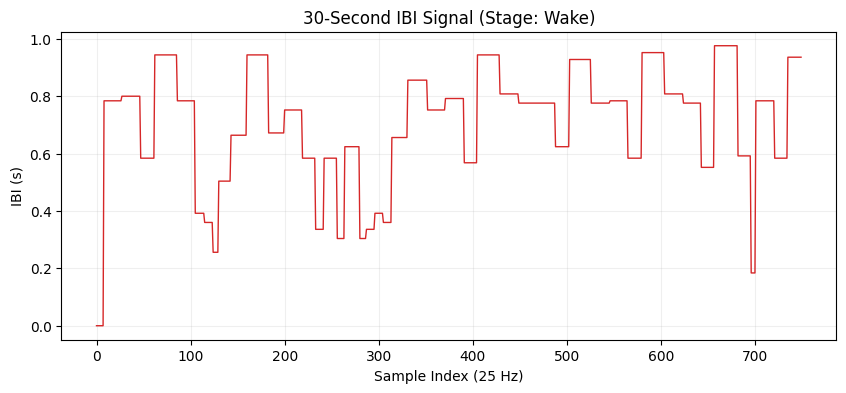

In [9]:
import matplotlib.pyplot as plt

def plot_ibi_sample(samples, idx=0):
    sample = samples[idx]
    data = sample['feature']
    label_map = {0: "Wake", 1: "N1", 2: "N2", 3: "N3", 4: "REM"}

    plt.figure(figsize=(10, 4))
    plt.plot(data, color='tab:red', linewidth=1)
    plt.title(f"30-Second IBI Signal (Stage: {label_map[sample['label']]})")
    plt.ylabel("IBI (s)")
    plt.xlabel("Sample Index (25 Hz)")
    plt.grid(True, alpha=0.2)
    plt.show()

# Look at the first sample to make sure it's not a flat line
plot_ibi_sample(samples, idx=0)

## WatchSleepNet Model Implementation (watchsleepnet.py)

This cell contains the actual neural network. We have added the TCN and Attention layers to match the paper's architecture exactly.

In [10]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from typing import Dict, Optional
from pyhealth.models import BaseModel

class ResidualBlock(nn.Module):
    """1D Residual Block for spatial feature extraction."""
    def __init__(self, in_channels: int, out_channels: int, stride: int = 1):
        super(ResidualBlock, self).__init__()
        self.conv1 = nn.Conv1d(in_channels, out_channels, kernel_size=5, stride=stride, padding=2)
        self.bn1 = nn.BatchNorm1d(out_channels)
        self.conv2 = nn.Conv1d(out_channels, out_channels, kernel_size=5, stride=1, padding=2)
        self.bn2 = nn.BatchNorm1d(out_channels)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv1d(in_channels, out_channels, kernel_size=1, stride=stride),
                nn.BatchNorm1d(out_channels)
            )

    def forward(self, x):
        identity = self.shortcut(x)
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += identity
        return F.relu(out)

class WatchSleepNet(BaseModel):
    """WatchSleepNet implementation following CHIL 2025 paper.

    Architecture:
    1. ResNet: Spatial feature extraction from IBI windows.
    2. TCN: Temporal convolutional network for long-range dependencies.
    3. Bi-LSTM + Attention: Sequential modeling and feature relevance.
    """
    def __init__(
        self,
        dataset=None,
        feature_size: int = 750,
        hidden_dim: int = 256,
        **kwargs
    ):
        super(WatchSleepNet, self).__init__(dataset, **kwargs)

        # Stage 1: ResNet (Spatial)
        # Input: (Batch, 1, 750) -> Output: (Batch, 256, ~47)
        self.resnet = nn.Sequential(
            ResidualBlock(1, 64, stride=2),           # 750 -> 375
            ResidualBlock(64, 128, stride=2),          # 375 -> 188
            ResidualBlock(128, 256, stride=2),         # 188 -> 94
            ResidualBlock(256, hidden_dim, stride=2),  # 94  -> 47
        )

        # Stage 2: TCN (Temporal)
        self.tcn = nn.Conv1d(hidden_dim, hidden_dim, kernel_size=5, dilation=2, padding=4)

        # Stage 3: Bi-LSTM + Attention
        self.lstm = nn.LSTM(hidden_dim, 128, batch_first=True, bidirectional=True)
        self.attention = nn.MultiheadAttention(embed_dim=256, num_heads=8, batch_first=True)

        # Final Classifier: 5 sleep stages
        self.fc = nn.Linear(256, 5)

    def forward(self, feature: torch.Tensor, label: torch.Tensor = None, **kwargs) -> Dict[str, torch.Tensor]:
        # 1. ResNet Spatial Extraction
        # Input: [Batch, 750] -> [Batch, 1, 750]
        x = feature.unsqueeze(1).float()
        x = self.resnet(x)  # [Batch, 256, ~47]

        # 2. TCN Temporal Extraction
        x = F.relu(self.tcn(x))  # [Batch, 256, ~47]

        # 3. Bi-LSTM
        x = x.transpose(1, 2)  # [Batch, ~47, 256]
        x, _ = self.lstm(x)    # [Batch, ~47, 256]

        # 4. Multi-head Attention
        attn_out, _ = self.attention(x, x, x)

        # 5. Global Pooling and Classify
        x = torch.mean(attn_out, dim=1)
        logits = self.fc(x)

        y_prob = torch.softmax(logits, dim=-1)

        loss = 0
        if label is not None:
            loss = F.cross_entropy(logits, label.long())

        return {"loss": loss, "y_prob": y_prob, "y_true": label}

## Model Verification and Training Prep

In [11]:
import torch
from torch.utils.data import DataLoader

# 1. Initialize the model
model = WatchSleepNet()

# 2. Convert samples to PyTorch DataLoader (Standard PyHealth/Torch way)
# For testing, we take a tiny batch of 4 samples
test_batch = samples[:4]
features = torch.stack([torch.tensor(s['feature']) for s in test_batch])
labels = torch.tensor([s['label'] for s in test_batch])

# 3. Run Forward Pass
output = model(feature=features, label=labels)

print(f"--- Model Verification ---")
print(f"Input batch shape: {features.shape}")
print(f"Output probability shape: {output['y_prob'].shape}") # Should be [4, 5]
print(f"Initial Loss: {output['loss'].item():.4f}")

if output['y_prob'].shape == (4, 5):
    print("✅ Model Architecture Verified!")

--- Model Verification ---
Input batch shape: torch.Size([4, 750])
Output probability shape: torch.Size([4, 5])
Initial Loss: 1.6068
✅ Model Architecture Verified!


## Training loop

In [12]:
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm

# 1. SPLIT SAMPLES (80% Train, 20% Test)
indices = list(range(len(samples)))
train_idx, test_idx = train_test_split(indices, test_size=0.2, random_state=42)

train_data = [samples[i] for i in train_idx]
test_data = [samples[i] for i in test_idx]

# 2. CREATE DATALOADERS
def collate_fn(batch):
    # PyHealth samples are dicts; we stack them into tensors
    features = torch.stack([torch.tensor(item['feature']).float() for item in batch])
    labels = torch.tensor([item['label'] for item in batch]).long()
    return features, labels

train_loader = DataLoader(train_data, batch_size=32, shuffle=True, collate_fn=collate_fn)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False, collate_fn=collate_fn)

# 3. SETUP TRAINING
device = "cuda" if torch.cuda.is_available() else "cpu"
model = WatchSleepNet()
model.to(device)

optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

# 4. TRAINING LOOP
print(f"Training WatchSleepNet on {device}...")
for epoch in range(1, 11): # 10 Epochs
    model.train()
    train_loss = 0
    for features, labels in tqdm(train_loader, desc=f"Epoch {epoch}", leave=False):
        features, labels = features.to(device), labels.to(device)

        optimizer.zero_grad()
        output = model(feature=features, label=labels)
        loss = output['loss']

        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    # 5. EVALUATION
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for features, labels in test_loader:
            features, labels = features.to(device), labels.to(device)
            output = model(feature=features)
            preds = torch.argmax(output['y_prob'], dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    acc = correct / total
    print(f"Epoch {epoch} | Loss: {train_loss/len(train_loader):.4f} | Test Acc: {acc:.4f}")

print("\n✅ Training Complete!")

Training WatchSleepNet on cuda...


Epoch 1:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch 1 | Loss: 1.1549 | Test Acc: 0.5456


Epoch 2:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch 2 | Loss: 1.1212 | Test Acc: 0.5400


...

Epoch 8 | Loss: 1.0832 | Test Acc: 0.5816


Epoch 9:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch 9 | Loss: 1.0752 | Test Acc: 0.4720


Epoch 10:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch 10 | Loss: 1.0658 | Test Acc: 0.5376

✅ Training Complete!


## TestAccuracy

In [13]:
from sklearn.metrics import classification_report, cohen_kappa_score
import numpy as np

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for features, labels in test_loader:
        features = features.to(device)
        output = model(feature=features)
        preds = torch.argmax(output['y_prob'], dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

kappa = cohen_kappa_score(all_labels, all_preds)
print(f"✅ Final Test Accuracy: {sum(np.array(all_preds) == np.array(all_labels)) / len(all_labels):.4f}")
print(f"✅ Final Cohen's Kappa: {kappa:.4f}")
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=["W", "N1", "N2", "N3", "R"]))

✅ Final Test Accuracy: 0.5376
✅ Final Cohen's Kappa: 0.2799

Classification Report:
              precision    recall  f1-score   support

           W       0.62      0.77      0.69       455
          N1       0.00      0.00      0.00        26
          N2       0.47      0.73      0.57       441
          N3       0.00      0.00      0.00       203
           R       0.00      0.00      0.00       125

    accuracy                           0.54      1250
   macro avg       0.22      0.30      0.25      1250
weighted avg       0.39      0.54      0.45      1250



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
